17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 300ms/step - accuracy: 0.7917 - loss: 0.4446 - val_accuracy: 0.8170 - val_loss: 0.4110
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 135s 277ms/step - accuracy: 0.8867 - loss: 0.2828 - val_accuracy: 0.8696 - val_loss: 0.3188
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 113s 362ms/step - accuracy: 0.9266 - loss: 0.1944 - val_accuracy: 0.8590 - val_loss: 0.3662


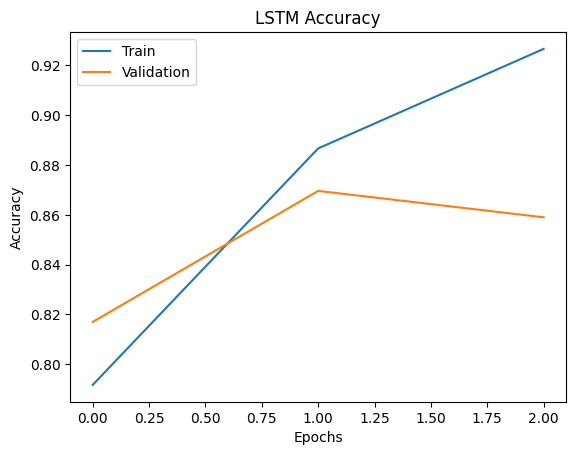

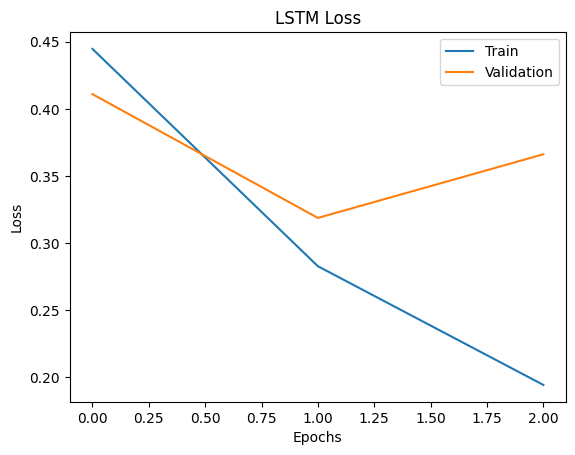

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

# 📈 Plot Graphs
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 11.9361 - val_loss: 13.5176
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 15.5823 - val_loss: 16.6368
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 16.6265 - val_loss: 16.6179
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 16.6081 - val_loss: 16.5301
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 16.4545 - val_loss: 16.3986


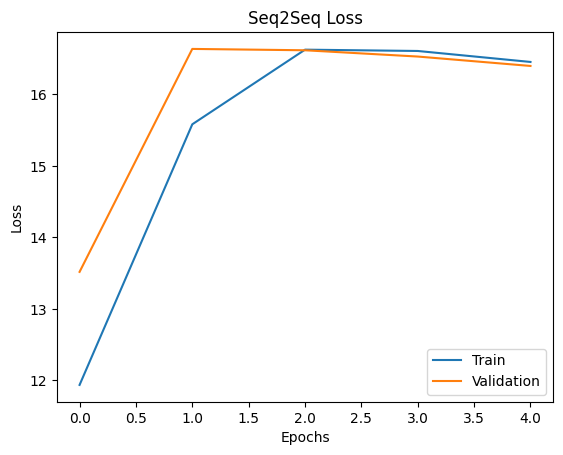

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

input_dim = 10
output_dim = 10
latent_dim = 64
timesteps = 5

encoder_inputs = Input(shape=(timesteps, input_dim))
encoder_lstm = LSTM(latent_dim, return_state=True)
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(timesteps, output_dim))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

decoder_dense = Dense(output_dim, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy')

encoder_input_data = np.random.random((1000, timesteps, input_dim))
decoder_input_data = np.random.random((1000, timesteps, output_dim))
decoder_target_data = np.random.random((1000, timesteps, output_dim))

history = model.fit([encoder_input_data, decoder_input_data],
                    decoder_target_data,
                    batch_size=32,
                    epochs=5,
                    validation_split=0.2)

# 📈 Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Seq2Seq Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Accuracy: 0.9


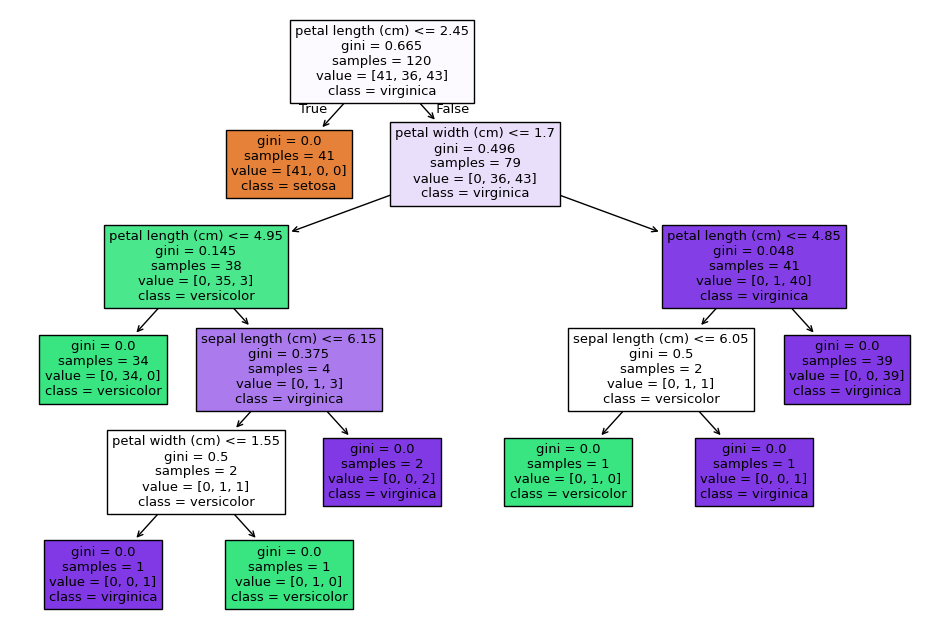

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

# 🌳 Tree Plot
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()